<a href="https://colab.research.google.com/github/JanaHolik/DSZ4083_FINAL-_PROJECT/blob/main/Projekt_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Customer Personality Analysis

In [ ]:
#Library import
# DATA ANALYSIS
import pandas as pd
import numpy as np
import random as rnd
import requests

from datetime import datetime
# VISUALIZATION
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
%matplotlib inline
# CLUSTERING
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, davies_bouldin_score, silhouette_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram
!pip install kneed
from kneed import KneeLocator
#from google.colab import data_table; data_table.enable_dataframe_formatter()






In [ ]:
#Dataset import
df = pd.read_csv("/content/sample_data/marketing_campaign.csv",sep='\t')
df.head(11)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# Convert Dt_Customer to a datetime format
pd.options.display.float_format = "{:.2f}".format # převod float na 2 desetinná místa
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
# Days since registration
df["Days_Since_Registration"]= (pd.Timestamp("now")- df["Dt_Customer"]).dt.days
df["Years_Since_Registration"] = (df["Days_Since_Registration"]/365.25).round (2)
#Drop original Dt_Customer column
df.drop("Dt_Customer", axis=1, inplace=True)

In [ ]:
#Create new features such as Age and Total_Children
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [ ]:
#Checking Unique Values
unique_values1 = df["Education"].unique()
print(unique_values1)
unique_values2 = df["Marital_Status"].unique()
print(unique_values2)

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [ ]:
# Remove the columns
df.drop (["Z_CostContact", "Z_Revenue", "Kidhome", "Teenhome", "ID"], axis=1, inplace=True)

In [ ]:
# Step - check null values in columns
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0


In [ ]:
#Education replace
df['Education']=df['Education'].replace({'Basic':'Undergraduate','2n Cycle':'Undergraduate','Graduation':'Postgraduate','Master':'Postgraduate','PhD':'Postgraduate'})
# marital status replace
df['Marital_Status']=df['Marital_Status'].replace({'Divorced':'Alone','Single':'Alone','Married':'In couple','Together':'In couple','Absurd':'Alone','Widow':'Alone','YOLO':'Alone'})
#Number rename
df=df.rename(columns={'NumWebPurchases': "Web",'NumCatalogPurchases':'Catalog','NumStorePurchases':'Store', "NumDealsPurchases": "Deals","NumWebVisitsMonth":"WebVisitMonth"})
df=df.rename(columns={'MntWines': "Wines",'MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweets','MntGoldProds':'Gold'})

In [ ]:
#Total amount customer spent
df["TotalMnt"] = df.Wines + df.Fruits+df.Meat+df.Fish+df.Sweets
#Customer´s spending on products
df["Income spent"] = df["TotalMnt"]/df["Income"]*100

In [ ]:
#Number of purchases the customer made
df["TotalPurchases"] = df.Deals +df.Web+df.Catalog+df.Store+df.WebVisitMonth

In [ ]:
#Number of campaigns that the customer accepted
df["Num_campaigns"] = df["AcceptedCmp1"]+df["AcceptedCmp2"]+df["AcceptedCmp3"] +df["AcceptedCmp4"]+df["AcceptedCmp5"] +df["Response"]
df.drop(["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"],axis=1,inplace=True)

In [ ]:
# Label Encoding for Education
education_encoder = LabelEncoder()
df["Education"]= education_encoder.fit_transform(df["Education"])
# Label Encoding for Marital_Status
marital_status_encoder = LabelEncoder()
df["Marital_Status"]= marital_status_encoder.fit_transform(df["Marital_Status"])

In [ ]:
#Checking and filling Missing Values

df.fillna(df.mean(numeric_only=True),inplace=True)

for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
df.head(11)
# mean = df["Income"].mean()

# #df['Income'] = df['Income'].fillna(mean)

,Year_Birth,Education,Marital_Status,Income,Recency,Wines,Fruits,Meat,Fish,Sweets,...,WebVisitMonth,Complain,Days_Since_Registration,Years_Since_Registration,Age,Total_Children,TotalMnt,Income spent,TotalPurchases,Num_campaigns
0,1957,0,0,58138.00,58,635,88,546,172,88,...,7,0,4638,12.70,68,0,1529,2.63,32,1
1,1954,0,0,46344.00,38,11,1,6,2,1,...,5,0,4088,11.19,71,2,21,0.05,11,0
2,1965,0,1,71613.00,26,426,49,127,111,21,...,4,0,4287,11.74,60,0,734,1.02,25,0
3,1984,0,1,26646.00,26,11,4,20,10,3,...,6,0,4114,11.26,41,1,48,0.18,14,0
4,1981,0,1,58293.00,94,173,43,118,46,27,...,5,0,4136,11.32,44,1,407,0.70,24,0
5,1967,0,1,62513.00,16,520,42,98,0,42,...,6,0,4268,11.69,58,1,702,1.12,28,0
6,1971,0,0,55635.00,34,235,65,164,50,49,...,6,0,4568,12.51,54,1,563,1.01,27,0
7,1985,0,1,33454.00,32,76,10,56,3,1,...,8,0,4392,12.02,40,1,146,0.44,18,0
8,1974,0,1,30351.00,19,14,0,24,3,3,...,9,0,4363,11.95,51,1,44,0.14,15,1
9,1950,0,1,5648.00,68,28,0,6,1,1,...,20,0,4083,11.18,75,2,36,0.64,22,1


In [ ]:
# Scaling the numeric columns using MinMaxScaler
columns_to_scale = ["Income", "Recency", "Wines","Fruits", "Meat", "Fish", "Sweets", "Gold", "Deals", "Web", "Catalog", "Store", "WebVisitMonth"]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[columns_to_scale])

scaled_df = pd.DataFrame(scaled_data, columns=columns_to_scale)

In [ ]:
#EDA
#Income - high variability (std =25,037) = outliers
#Kidhome - median close to zero (most households have no kids or teens)
#Wines, Fruits,.. -  - high variability = outliers, many custeomers spent zero (minumum = 0)
#Purchase, Web - median purchases are low, indicating many customers made few purchases
#AcceptedCmpX - campaign success rates are low (median -0,07)
df.describe()

,Year_Birth,Education,Marital_Status,Income,Recency,Wines,Fruits,Meat,Fish,Sweets,...,WebVisitMonth,Complain,Days_Since_Registration,Years_Since_Registration,Age,Total_Children,TotalMnt,Income spent,TotalPurchases,Num_campaigns
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,...,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,1968.81,0.11,0.64,52247.25,49.11,303.94,26.30,166.95,37.53,27.06,...,5.32,0.01,4328.58,11.85,56.19,0.95,561.78,0.90,20.18,0.45
std,11.98,0.32,0.48,25037.80,28.96,336.60,39.77,225.72,54.63,41.28,...,2.43,0.10,202.12,0.55,11.98,0.75,576.61,1.65,7.29,0.89
min,1893.00,0.00,0.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,3975.00,10.88,29.00,0.00,4.00,0.00,0.00,0.00
25%,1959.00,0.00,0.00,35538.75,24.00,23.75,1.00,16.00,3.00,1.00,...,3.00,0.00,4155.75,11.38,48.00,0.00,55.00,0.19,14.00,0.00
50%,1970.00,0.00,1.00,51741.50,49.00,173.50,8.00,67.00,12.00,8.00,...,6.00,0.00,4330.50,11.86,55.00,1.00,341.00,0.71,19.00,0.00
75%,1977.00,0.00,1.00,68289.75,74.00,504.25,33.00,232.00,50.00,33.00,...,7.00,0.00,4504.00,12.33,66.00,1.00,964.00,1.44,25.00,1.00
max,1996.00,1.00,1.00,666666.00,99.00,1493.00,199.00,1725.00,259.00,263.00,...,20.00,1.00,4674.00,12.80,132.00,3.00,2491.00,70.66,46.00,5.00


In [ ]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Recency,Wines,Fruits,Meat,Fish,Sweets,...,WebVisitMonth,Complain,Days_Since_Registration,Years_Since_Registration,Age,Total_Children,TotalMnt,Income spent,TotalPurchases,Num_campaigns
0,1957,0,0,58138.00,58,635,88,546,172,88,...,7,0,4638,12.70,68,0,1529,2.63,32,1
1,1954,0,0,46344.00,38,11,1,6,2,1,...,5,0,4088,11.19,71,2,21,0.05,11,0
2,1965,0,1,71613.00,26,426,49,127,111,21,...,4,0,4287,11.74,60,0,734,1.02,25,0
3,1984,0,1,26646.00,26,11,4,20,10,3,...,6,0,4114,11.26,41,1,48,0.18,14,0
4,1981,0,1,58293.00,94,173,43,118,46,27,...,5,0,4136,11.32,44,1,407,0.70,24,0


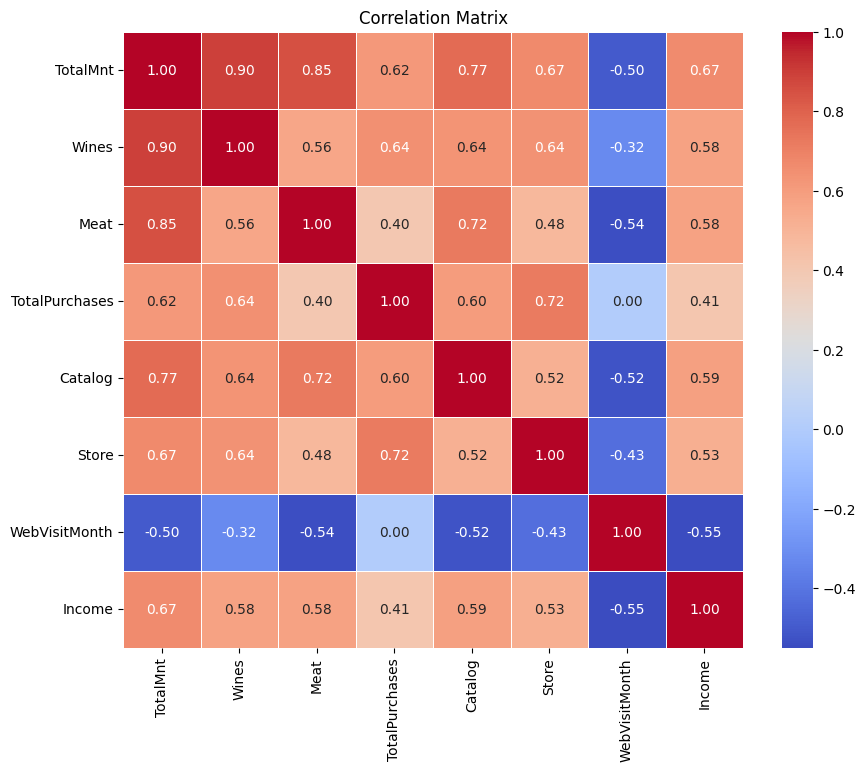

In [ ]:
#Finding Correlation using Heatmaps
correlation_matrix = df[[
"TotalMnt", # total expenses of wines, meat,...
"Wines", #expenses on wines
"Meat",  #expenses on meat
"TotalPurchases",   #Number of total purchases via catalog, store,...
"Catalog", #Number of purchases
"Store", #Number of purchases
"WebVisitMonth",
"Income",
]].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True,cmap="coolwarm",fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()







In [ ]:
# #KORELACE

# # 0,60–0,79: silná korelace

# # 0,80–1,00: velmi silná korelace


# Strong Postive Correlations
## Wine versus Catalog = 0.64
## Wine versus Store = 0.64
## Meat versus Catalog = 0.72
## Store versus Wines = 0.64
## Store versus TotalPurchase = 0.72
## Wine versus TotalMnt(expenses) = 0.90
## Income versus TotalMnt = 0.67

# Střední pozitivní korelace
##Income versus Wine = 0.58
##Income versus Meat = 0.58
##Income versus Catalog = 0.59
##Income versus TotalMnt(Expenses) = 0.67

#Negative Correlations
##WebVisitMonth versus Income = minus 0.55
##WebVisitMonth versus Meat = minus 0.54
##WebVisitMonth versus Catalog = minus 0.52



# Weaker or Neutral Correlations
## Education
## Marital_Status
## Recency
## Complain
## Age
## Years_Since_Registration
## Total_Children
## Num_campaigns
## Fruits
## Fish
## Gold
## Deals





Text(0, 0.5, 'SSE')

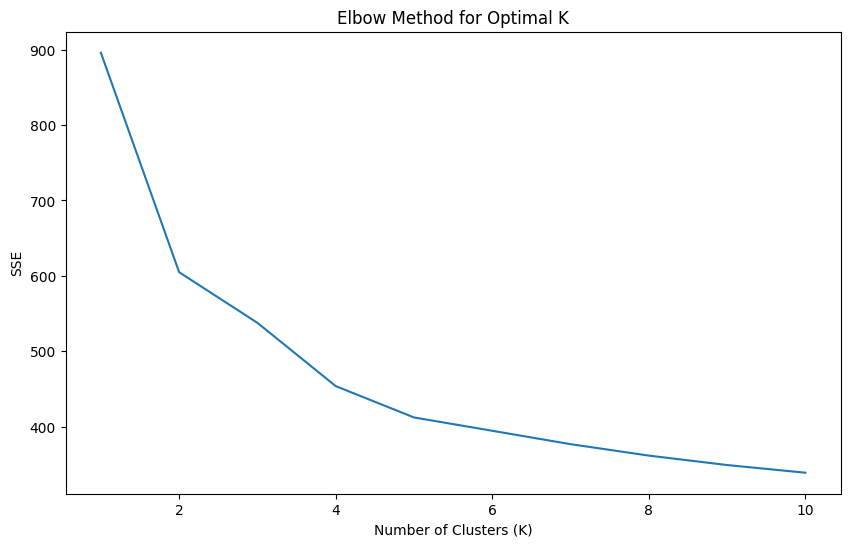

In [ ]:
sse = []
for k in range (1,11):
  kmeans = KMeans (n_clusters=k, random_state=42)
  kmeans.fit(scaled_df)
  sse.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,11),sse)
plt. title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")

#The Elbow Method helps identify the optimal number of clusters by plotting the Sum of Squared Errors (SSE) for different values of K.
#The plot above shows how SSE decreases as the number of clusters increases.
#The output indicates that the optimal number of clusters is 3. This choice balances model complexity and performance.

In [ ]:
kneedle =KneeLocator(range(1,11), sse, curve ="convex", direction="decreasing")
print ("The best k for your model is:", kneedle.elbow)

The best k for your model is: 4


In [ ]:
kmeans= KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

# Souhrnné statistiky podle clusterů
cluster_summary = df.groupby('Cluster').agg(['mean', 'min', 'max'])
cluster_summary = cluster_summary.T
pd.set_option("display.max_rows", None)  #zobrazení všech řádků

print(cluster_summary)
y_pred = kmeans.fit_predict(scaled_df)
y_pred

Cluster                               0         1         2         3
Year_Birth               mean   1970.43   1965.92   1968.87   1968.03
                         min    1893.00   1941.00   1899.00   1943.00
                         max    1996.00   1995.00   1995.00   1993.00
Education                mean      0.15      0.06      0.13      0.10
                         min       0.00      0.00      0.00      0.00
                         max       1.00      1.00      1.00      1.00
Marital_Status           mean      0.66      0.64      0.65      0.59
                         min       0.00      0.00      0.00      0.00
                         max       1.00      1.00      1.00      1.00
Income                   mean  37863.70  66395.36  74205.80  73280.25
                         min    1730.00  30522.00  32632.00  31907.00
                         max  666666.00 160803.00 105471.00 102160.00
Recency                  mean     48.43     53.35     20.68     70.22
                    

array([3, 0, 2, ..., 1, 1, 0], dtype=int32)

In [ ]:
scaled_df["Cluster"] = y_pred

In [ ]:
#After determining K=4, we fit the K-Means model and predict the cluster labels.

In [ ]:
# Inverse transform the scaled data
inversed_data = scaler.inverse_transform(scaled_df.drop(columns=["Cluster"], errors = "igonere"))
# Convert the inversed data to a DataFrame and add column names from the original scaled data
inversed_df = pd.DataFrame(inversed_data, columns=scaled_df.drop(columns=["Cluster"],errors="ignore").columns)
#Add the KMeans labels (from the kmeans clustering step)
inversed_df["KMeans"] = kmeans.labels_
#Display the first few rows of the inversed DataFrame
inversed_df.head()


,Income,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Deals,Web,Catalog,Store,WebVisitMonth,KMeans
0,58138.00,58.00,635.00,88.00,546.00,172.00,88.00,88.00,3.00,8.00,10.00,4.00,7.00,2
1,46344.00,38.00,11.00,1.00,6.00,2.00,1.00,6.00,2.00,1.00,1.00,2.00,5.00,0
2,71613.00,26.00,426.00,49.00,127.00,111.00,21.00,42.00,1.00,8.00,2.00,10.00,4.00,2
3,26646.00,26.00,11.00,4.00,20.00,10.00,3.00,5.00,2.00,2.00,0.00,4.00,6.00,0
4,58293.00,94.00,173.00,43.00,118.00,46.00,27.00,15.00,5.00,5.00,3.00,6.00,5.00,1


In [ ]:
#Interpreting K-Means Clusters - DOPLNIT!!!!!
# Cluster 0
# Cluster 1
# Cluster 2

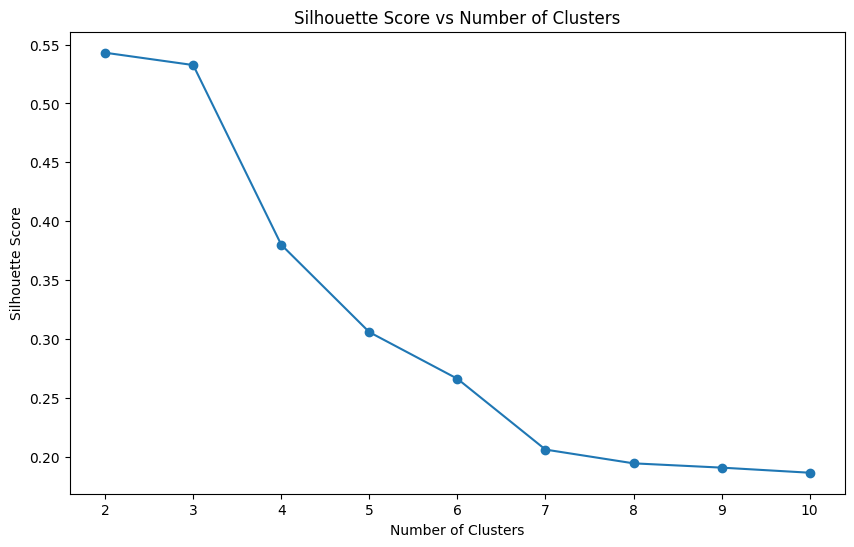

In [ ]:
#Hierarchical Clustering using the Agglomerative Method
silhouette_scores = []
k_range = range (2,11)

for k in k_range:
    agglomerative = AgglomerativeClustering(n_clusters=k, linkage="ward")
    cluster_labels = agglomerative.fit_predict(scaled_df)

    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10,6))
plt.plot(k_range, silhouette_scores, marker="o")  # je to písmeno, ne nula
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=2, metric= "euclidean", linkage="ward")
y_hc = hc.fit_predict(scaled_df)

In [ ]:
inversed_df["Agglo"] = y_hc
inversed_df.head()

,Income,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Deals,Web,Catalog,Store,WebVisitMonth,KMeans,Agglo
0,58138.00,58.00,635.00,88.00,546.00,172.00,88.00,88.00,3.00,8.00,10.00,4.00,7.00,2,0
1,46344.00,38.00,11.00,1.00,6.00,2.00,1.00,6.00,2.00,1.00,1.00,2.00,5.00,0,1
2,71613.00,26.00,426.00,49.00,127.00,111.00,21.00,42.00,1.00,8.00,2.00,10.00,4.00,2,0
3,26646.00,26.00,11.00,4.00,20.00,10.00,3.00,5.00,2.00,2.00,0.00,4.00,6.00,0,1
4,58293.00,94.00,173.00,43.00,118.00,46.00,27.00,15.00,5.00,5.00,3.00,6.00,5.00,1,0


In [ ]:
#1. Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=2)
df['Cluster'] = agglo.fit_predict(scaled_df)

# 2. Souhrnné statistiky
cluster_summary = df.groupby('Cluster').agg(['mean', 'min', 'max'])

# 3. Transpozice pro požadovaný vzhled
cluster_summary = cluster_summary.T

# 4. Přejmenování sloupců (volitelné)
cluster_summary = cluster_summary.rename(columns={i: f'Cluster {i}' for i in cluster_summary.columns})
cluster_summary.columns.name = "Agglo"

# 5. Zobrazení všech řádků (volitelné)
pd.set_option("display.max_rows", None)

print(cluster_summary)

Agglo                          Cluster 0  Cluster 1
Year_Birth               mean    1966.88    1970.44
                         min     1899.00    1893.00
                         max     1995.00    1996.00
Education                mean       0.08       0.15
                         min        0.00       0.00
                         max        1.00       1.00
Marital_Status           mean       0.63       0.66
                         min        0.00       0.00
                         max        1.00       1.00
Income                   mean   69116.11   37965.05
                         min    30522.00    1730.00
                         max   105471.00  666666.00
Recency                  mean      49.93      48.41
                         min        0.00       0.00
                         max       99.00      99.00
Wines                    mean     584.26      66.60
                         min        5.00       0.00
                         max     1493.00     462.00
Fruits      

In [ ]:
#DOPLNIT
#Cluster 0
#Cluster 1

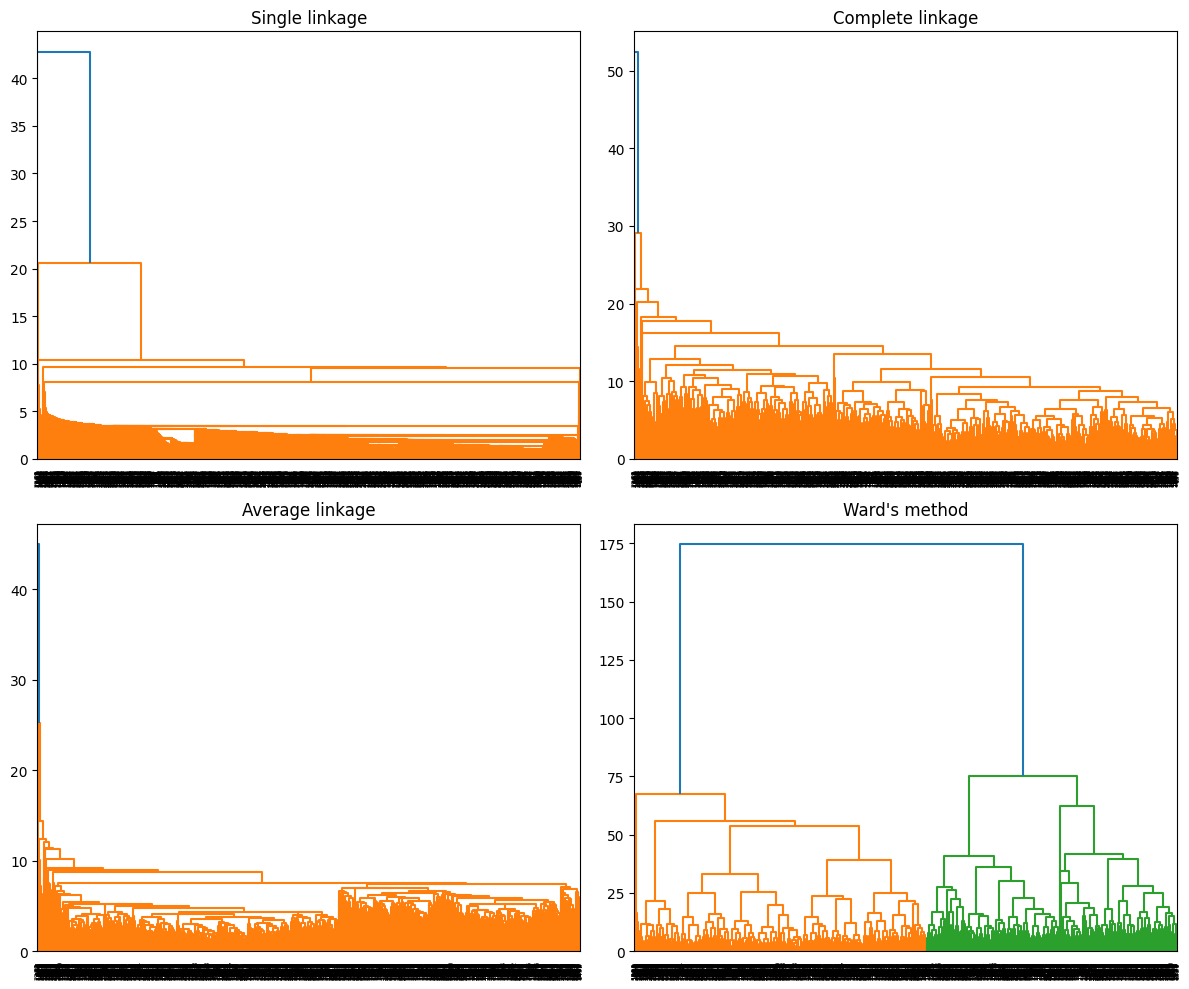

In [ ]:
# Standardizace dat (doporučeno)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Single linkage
Z_single = linkage(scaled_data, method='single')

# Complete linkage
Z_complete = linkage(scaled_data, method='complete')

# Average linkage
Z_average = linkage(scaled_data, method='average')

# Wardova metoda
Z_ward = linkage(scaled_data, method='ward')

# Vykreslení dendrogramů pro porovnání
plt.figure(figsize=(12, 10))

plt.subplot(221)
dendrogram(Z_single)
plt.title('Single linkage')

plt.subplot(222)
dendrogram(Z_complete)
plt.title('Complete linkage')

plt.subplot(223)
dendrogram(Z_average)
plt.title('Average linkage')

plt.subplot(224)
dendrogram(Z_ward)
plt.title("Ward's method")

plt.tight_layout()
plt.show()


# Nová sekce

## **Data Visualization**


co budeme vizualizovat:
    total accepted campaign (nejvíce REsponse)
    correlation between Income and Total expenses and then followed by Total Purchases, and another correlation is between Total expenses and Total Purchases
    remove the big outliers(Income?)
    distribution of the income (Income versus Count)
    check if the number of successful campaigns increased sales (num_Cmp versus Totla Mnt)
    !!! Birth year min. je 1893-1900!!!
    nastavení Cluster

